# Variable Relationships: Covariance, Correlation

Compare covariance, correlation, and regression for relationships between variables. Covers interpretation, assumptions, pitfalls, and Python examples.


## 1. Relationships between Variables: Understanding How Data Moves Together

Understanding how variables relate to one another is fundamental to data science and statistical analysis. Whether we're exploring patterns in data, building predictive models, or testing hypotheses, the ability to quantify and interpret relationships between variables enables us to extract meaningful insights from complex datasets and make informed decisions based on empirical evidence.

## 2. Introduction

In real-world data, variables rarely exist in isolation. Customer age might relate to purchasing behavior, temperature might affect sales patterns, and education level might correlate with income. Recognizing and quantifying these relationships forms the backbone of exploratory data analysis, predictive modeling, and causal inference.

This notebook explores the fundamental tools for measuring and interpreting relationships between variables. We begin with covariance and correlation, which quantify the strength and direction of linear associations. We then examine regression analysis (superficially as we have a whole notebook dedicated to it), which models these relationships explicitly to enable prediction and inference. Finally, we address one of the most important distinctions in data science: the difference between correlation and causation. Understanding when an observed association reflects a causal mechanism rather than a spurious correlation helps avoid misinterpretation and supports sound conclusions.

By the end of this notebook, you'll understand how to measure variable relationships, model them mathematically, interpret them correctly, and recognize the boundaries of what these methods can tell us about the underlying data-generating process.

## 3. Covariance: Measuring Joint Variability

Covariance quantifies how two variables change together. When one variable tends to be above its mean at the same time the other is above its mean, they have positive covariance. When one tends to be above its mean while the other is below its mean, they have negative covariance. A covariance near zero suggests little linear relationship between the variables.

The population Covariance between two Variables $X$ and $Y$ is defined as:

$$ Cov(X,Y) - E[(X - \mu_X)(Y - \mu_Y)]$$

where 
1. $E[.]$: Expected Value operator
2. $mu_X$ : $E[X]$: Population mean of $X$ 
3. $mu_Y$ : $E[Y]$: Population mean of $Y$ 

In practice, we work with sample data and estimate covariance using the sample covariance:


$$s_XY = (1 / n - 1) * \sum_{i=1}^{n}{x_{i} - \hat{x}}{y_{i} - \hat{y}}$$

where 
1. n: sample size
2. $x_i,y_i$ : individual obeservations
3. $\hat(x),\hat(y)$: Sample means

The interpretation of covariance is straightforward in terms of direction: positive values indicate variables tend to move together in the same direction, while negative values indicate they move in opposite directions. However, the magnitude of covariance is difficult to interpret because it depends on the units and scales of the variables. A covariance of 100 might indicate a strong relationship for variables measured in small units, but a weak relationship for variables measured in large units. This limitation motivates the need for a standardized measure of association.

To better understand how covariance captures joint variability, consider the geometric interpretation. Each data point contributes to the covariance based on whether both variables are above their means (positive contribution), both below their means (positive contribution), or one above and one below (negative contribution). The following visualization shows this structure and how different quadrants contribute to the overall covariance measure.

Means:  X = 4.61,  Y = 4.64
Quadrant sums: Q1=145.32, Q2=-12.33, Q3=158.78, Q4=-4.50
Total covariance contribution: 287.28


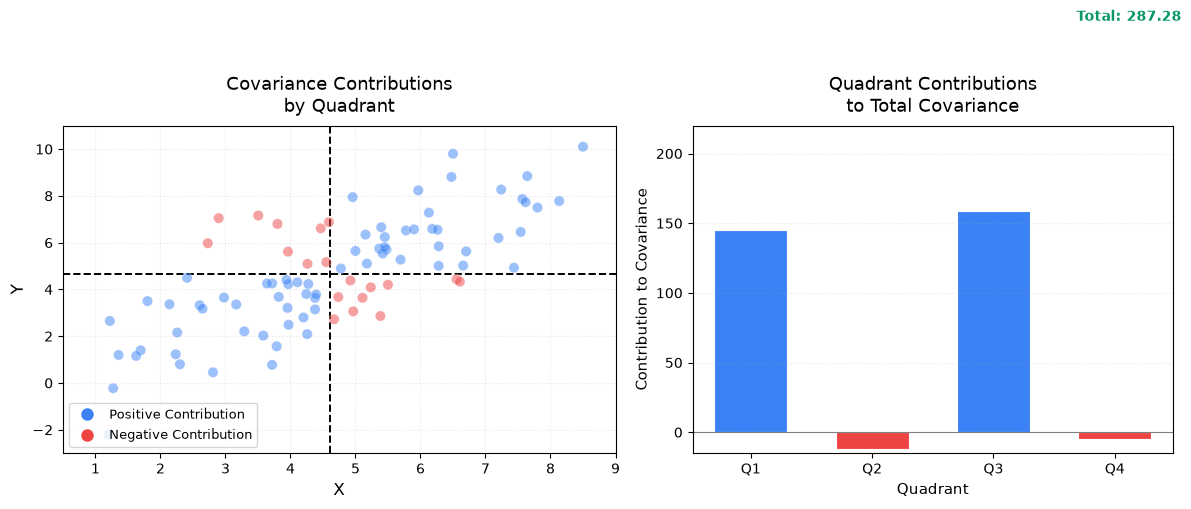

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# Generate Synthetic data that looks like the figure
np.random.seed(42)

#main cluod with positive correlation
n = 80
x = np.random.normal(4.8,1.8,n)
y = 0.9 * x + np.random.normal(0.5, 1.6, n)

extra_x = np.array([1.2, 1.8, 2.3, 6.5, 7.2, 7.8, 8.5, 3.8, 4.2, 5.5])
extra_y = np.array([-2.2, 3.5, 0.8, 9.8, 6.2, 7.5, 10.1, 6.8, 2.8, 4.2])
x = np.concatenate([x,extra_x])
y = np.concatenate([y, extra_y])

# Compute means and pre-point contributions
mean_x = np.mean(x)
mean_y = np.mean(y)


dx = x - mean_x
dy = y - mean_y

# contribution of each point to the (sample) covariance
contrib = dx * dy

#quandrant masks
q1 = (dx > 0) & (dy >0)
q2 = (dx < 0) & (dy >0)
q3 = (dx < 0) & (dy < 0)
q4 = (dx > 0) & (dy < 0)


sum_q1 = contrib[q1].sum()
sum_q2 = contrib[q2].sum()
sum_q3 = contrib[q3].sum()
sum_q4 = contrib[q4].sum()
total_cov = contrib.sum()


print(f"Means:  X = {mean_x:.2f},  Y = {mean_y:.2f}")
print(f"Quadrant sums: Q1={sum_q1:.2f}, Q2={sum_q2:.2f}, Q3={sum_q3:.2f}, Q4={sum_q4:.2f}")
print(f"Total covariance contribution: {total_cov:.2f}")

#Create Figure

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5),
                               gridspec_kw={'width_ratios': [1.15, 1]})

colors = np.where(contrib >=0 ,'#3b82f6', '#ef4444')   # blue / red)
ax1.scatter(x,y, c=colors,s=55, alpha=0.5, edgecolors ='white', linewidth=0.4,zorder=3)

# Mean lines
ax1.axvline(mean_x, color='black', linestyle='--', linewidth=1.4, zorder=2)
ax1.axhline(mean_y, color='black', linestyle='--', linewidth=1.4, zorder=2)

ax1.set_xlabel('X', fontsize=12)
ax1.set_ylabel('Y', fontsize=12)
ax1.set_title('Covariance Contributions\nby Quadrant', fontsize=13, pad=10)
ax1.set_xlim(0.5, 9)
ax1.set_ylim(-3, 11)
ax1.grid(True, alpha=0.3, linestyle=':')


# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3b82f6',
           markersize=10, label='Positive Contribution'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#ef4444',
           markersize=10, label='Negative Contribution')
]
ax1.legend(handles=legend_elements, loc='lower left', frameon=True, fontsize=9)

# ---------- Right: Bar chart ----------
quadrants = ['Q1', 'Q2', 'Q3', 'Q4']
values = [sum_q1, sum_q2, sum_q3, sum_q4]
bar_colors = ['#3b82f6', '#ef4444', '#3b82f6', '#ef4444']

bars = ax2.bar(quadrants, values, color=bar_colors, width=0.6, edgecolor='white', linewidth=0.8)

# Horizontal line for total
ax2.axhline(total_cov, color='#059669', linestyle='--', linewidth=2, label=f'Total: {total_cov:.2f}')
ax2.text(3.55, total_cov + 8, f'Total: {total_cov:.2f}', color='#059669',
         fontsize=10, fontweight='bold', ha='right')

ax2.set_ylabel('Contribution to Covariance', fontsize=11)
ax2.set_xlabel('Quadrant', fontsize=11)
ax2.set_title('Quadrant Contributions\nto Total Covariance', fontsize=13, pad=10)
ax2.set_ylim(-15, 220)
ax2.grid(True, axis='y', alpha=0.3, linestyle=':')
ax2.axhline(0, color='gray', linewidth=0.8)

plt.tight_layout()
plt.savefig("Plots/Covariane_Comparision.png", dpi=150)
plt.show()

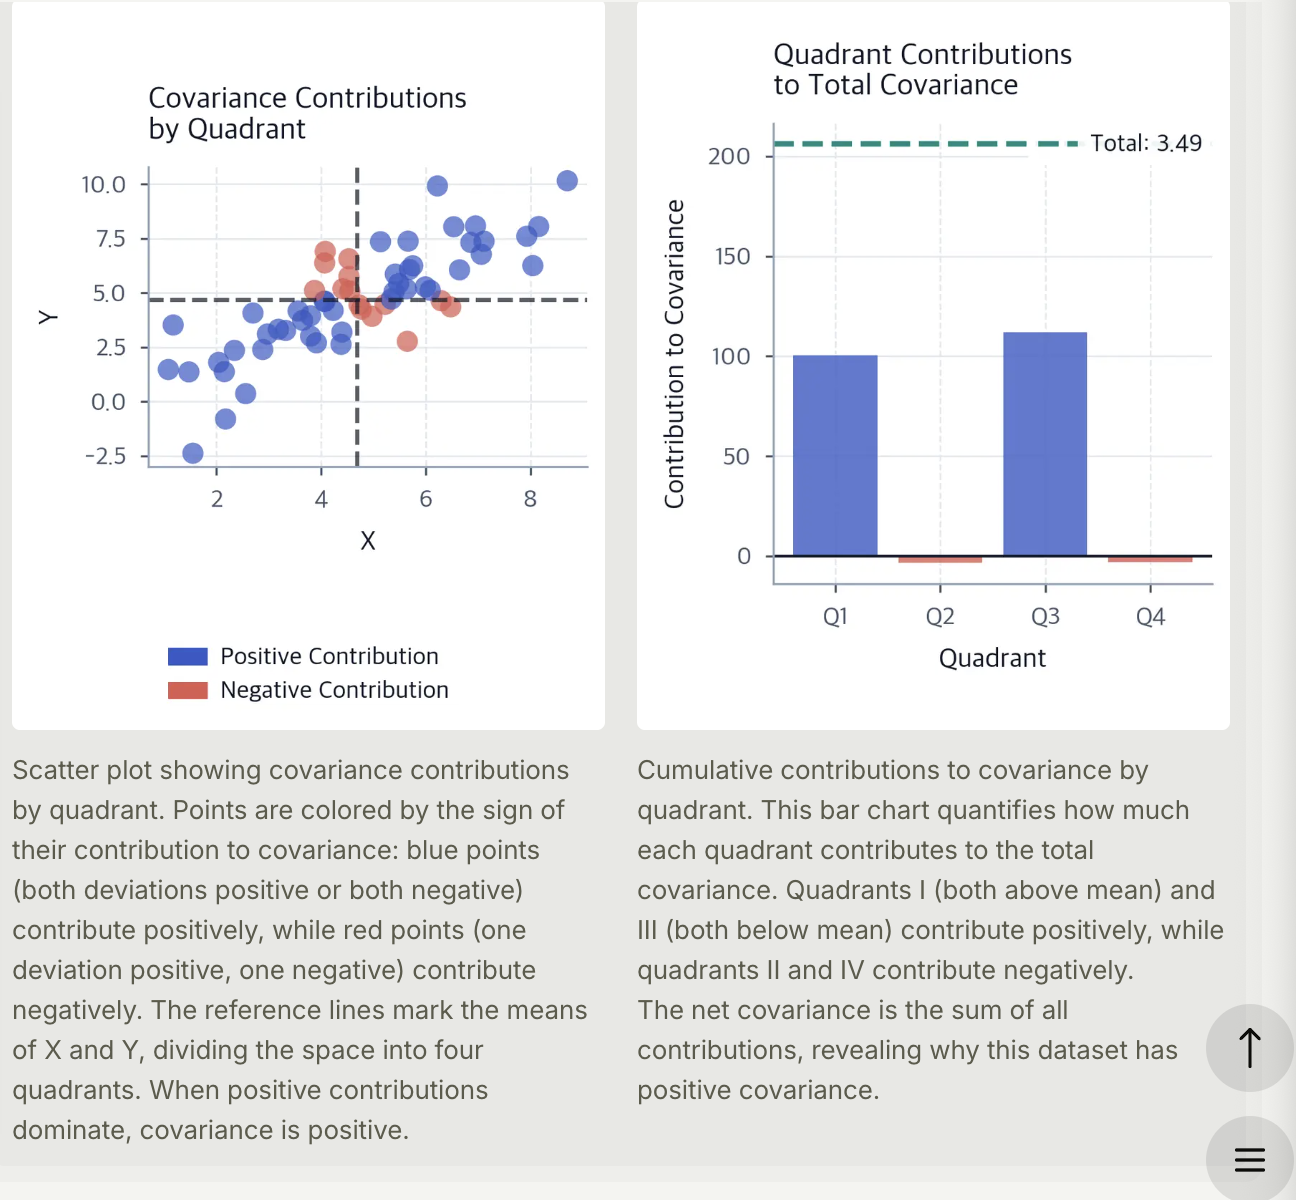

## 4. Correlation: Standardized Reltionship Strength

Correlation addresses the scale-dependence problem of covariance by standardizing the measure. The Pearson correlation coefficient, the most commonly used correlation measure, divides the covariance by the product of the standard deviations of both variables. This normalization ensures that correlation always falls between `-1` and `+1`, regardless of the original units.

The population correlation coefficient is :

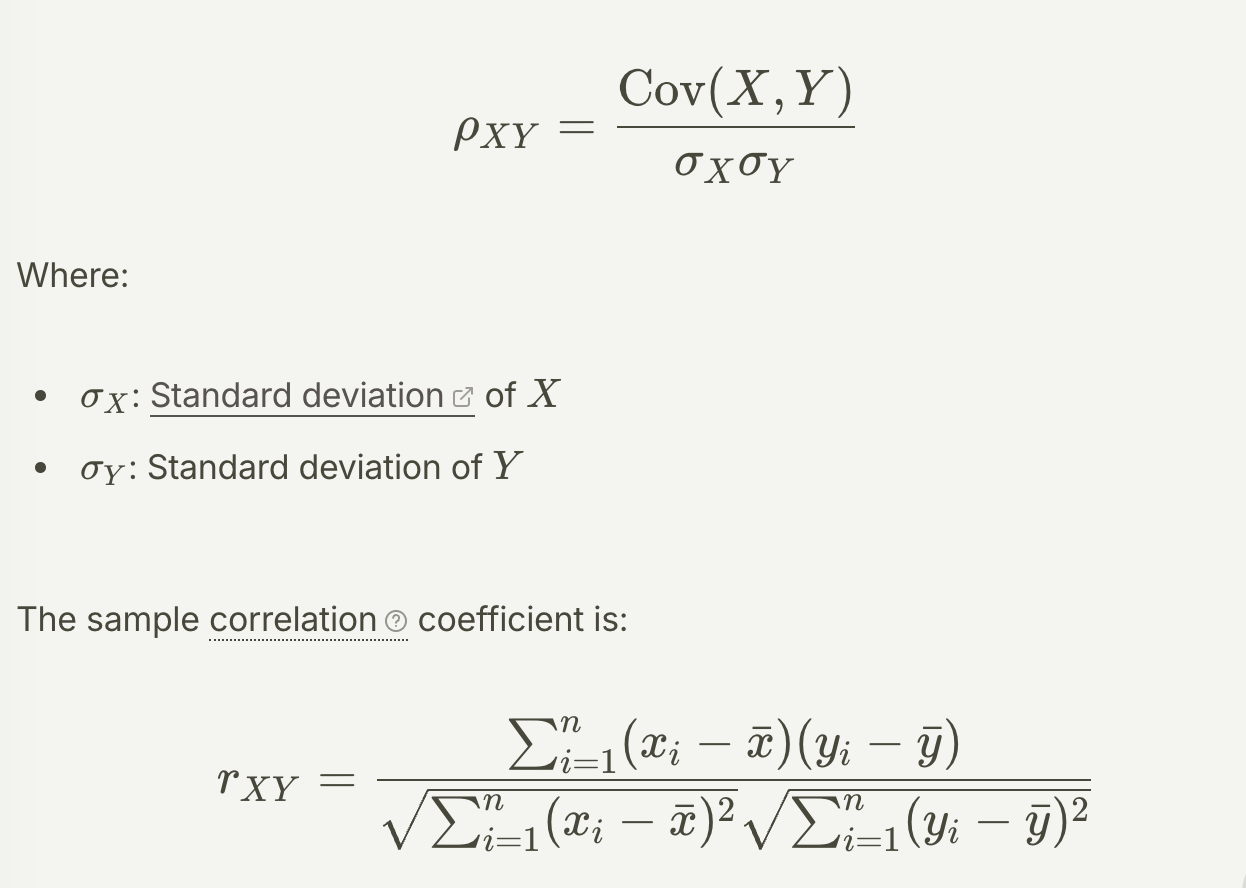

Correlation values have clear interpretations. A correlation of 
`r = 1` indicates a perfect positive linear relationship where all points fall exactly on a line with positive slope. A correlation of 
`r = −1` indicates a perfect negative linear relationship. A correlation of 
`r = 0` suggests no linear relationship, though non-linear relationships may still exist. In practice, correlations between `0.7` and `1.0 or -0.7` and `-1.0` are generally considered strong, `0.3 to 0.7`(or ` -0.3 to -0.7`) moderate, and below `0.3` weak, though these thresholds vary by field and context.

The following visualization demonstrates these different correlation patterns, showing how various relationships between variables manifest in scatter plots and their corresponding correlation coefficients.

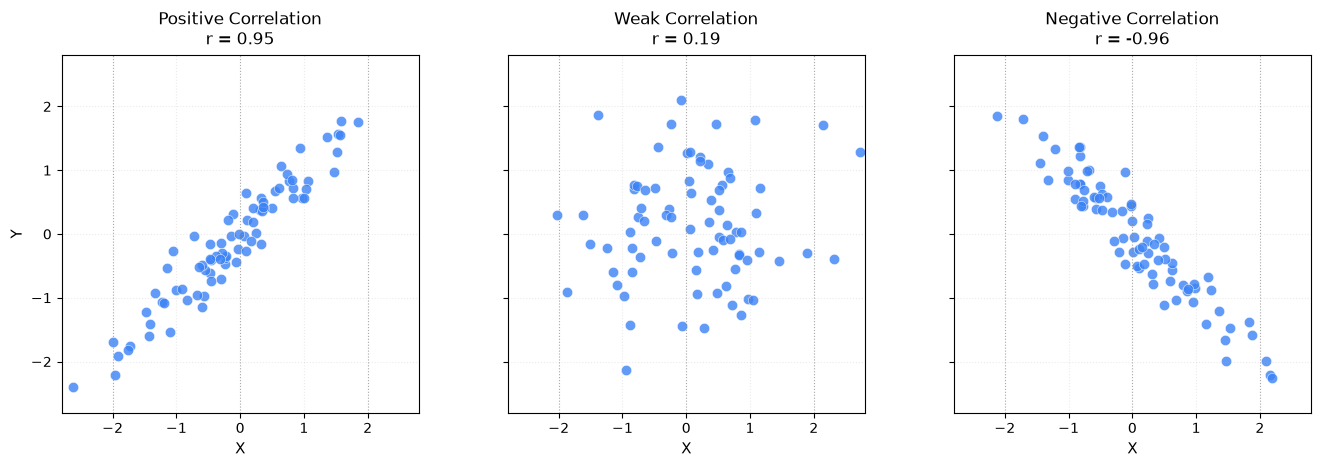

In [5]:
import numpy as np
import matplotlib.pyplot as plt


np.random.seed(42)
n = 80

x1 = np.random.normal(0,1,n)
y1 = 0.95 * x1 + np.random.normal(0,0.3, n)


x2 = np.random.normal(0,1,n)
y2 = 0.19 * x2 + np.random.normal(0,1.0,n)

x3 = np.random.normal(0, 1, n)
y3 = -0.96 * x3 + np.random.normal(0, 0.28, n)


fig, axes = plt.subplots(1,3, figsize=(14,4.5), sharey=True)

datasets = [
    (x1, y1, "Positive Correlation\nr = 0.95", 0.95),
    (x2, y2, "Weak Correlation\nr = 0.19", 0.19),
    (x3, y3, "Negative Correlation\nr = -0.96", -0.96)
]


for ax, (x,y, title, r) in zip(axes, datasets):
    ax.scatter(x,y,c='#3b82f6', s=55, alpha=0.8, edgecolors='white', linewidth=0.4)
    for v in [-2,0,2]:
        ax.axvline(v, color='grey', linestyle=':',linewidth=0.8, alpha=0.6)

        ax.set_xlim(-2.8,2.8)
        ax.set_ylim(-2.8,2.8)
        ax.set_xlabel('X', fontsize=11)
        ax.set_title(title, fontsize=12, pad=8)
        ax.grid(True, alpha=0.25, linestyle=':')
        ax.set_aspect('equal', adjustable='box')

    axes[0].set_ylabel('Y', fontsize=11)

plt.tight_layout()
plt.savefig("Plots/Correlation_Comparision.png", dpi=150)
plt.show()

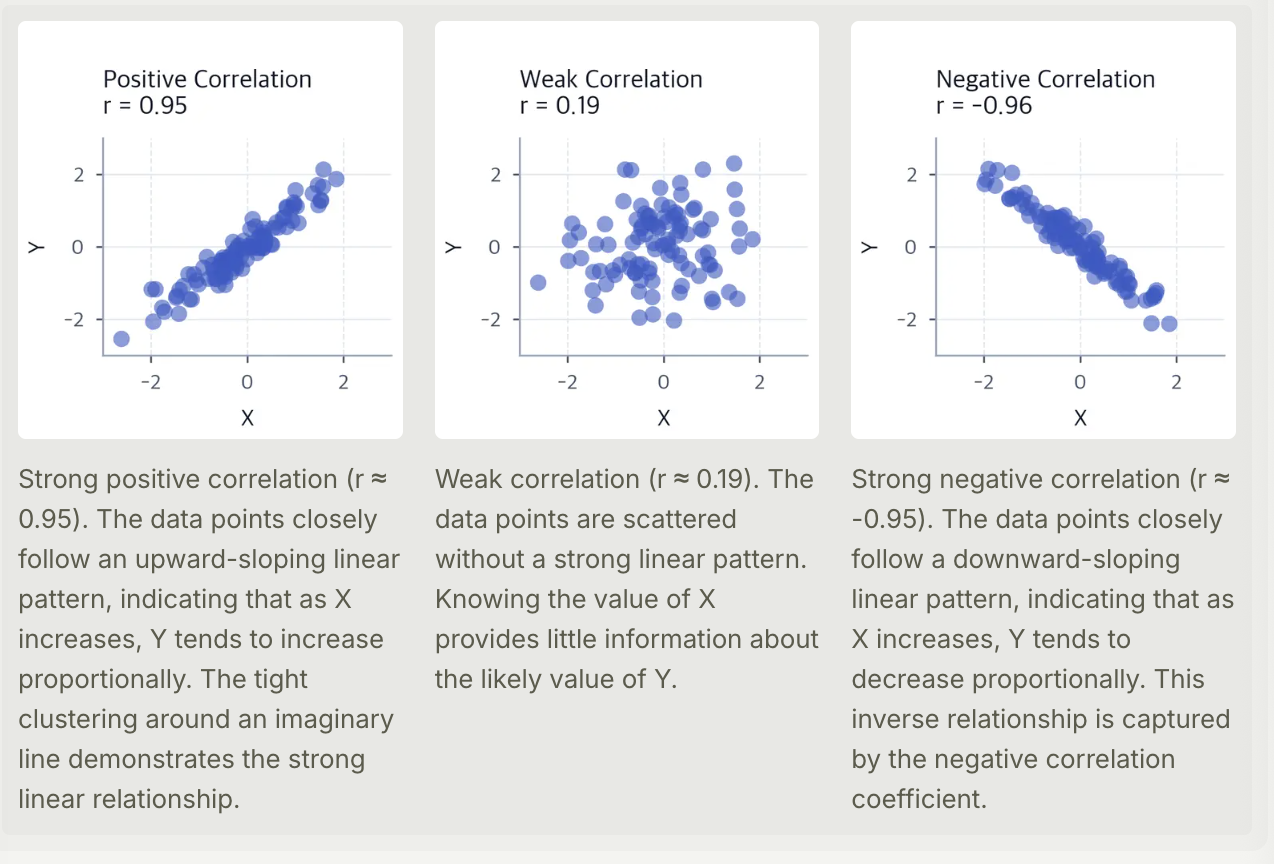

Correlation measures only linear relationships. Two variables can have zero correlation yet still be strongly related through a non-linear pattern such as a quadratic or sinusoidal relationship. This limitation makes visualization essential: plotting your data before relying solely on correlation coefficients helps identify non-linear patterns that correlation cannot detect. The following example demonstrates this limitation with a quadratic relationship where the correlation coefficient is near zero despite a clear pattern.